# Binned photon counts
## 1 fluorophore, S0 S1 system

In [4]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import src.fluorophore_systems as fs
import src.figures as fi
from scipy.stats import poisson
import src.distributions as d

%load_ext autoreload
%autoreload 2

In [5]:
rate_dict = dict(k_S0_S1=[1e8, "excitation"],
                 k_S1_S0=[1e9, "emission"])

In [6]:
system = fs.GeneralModel(number=1,  distances=1, rates=rate_dict)

In [7]:
system.simulate(n_steps=10000000, seed=99)

In [8]:
system.process()

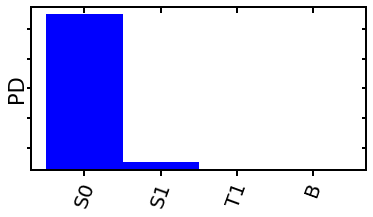

In [13]:
fig, ax = fi.FigureCollection(system).populations(mode="single_states", single_fluorophores=False, 
                                                  bins=np.arange(0, 5)-0.5)

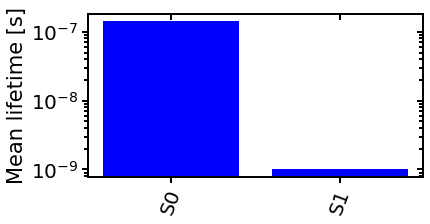

In [9]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="mean",
                                                single_fluorophores=False)

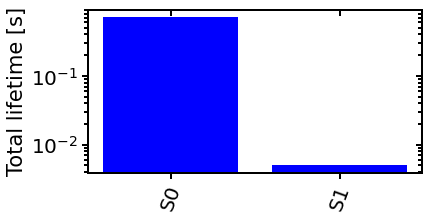

In [14]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="total",
                                                single_fluorophores=False)

## 0.1 µs

In [19]:
system.emitters(unit="s", resample="0.1us", photon_collection=1)
system.fcs(normalize=True, log=True, m=2, deltat=1e-7)

[0.69993473]
1.3813925320814602


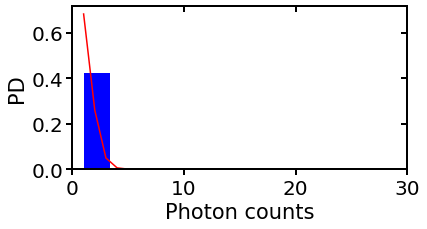

In [20]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, pois=True, 
                                                      bins=3, xlim=[0, 30])

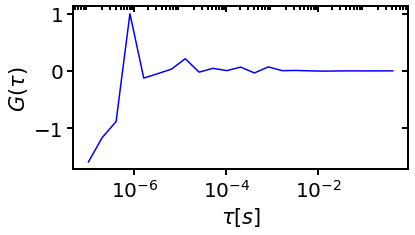

In [21]:
fig, ax = fi.FigureCollection(system).fcs(log=True, normalize_to=4)

## 1 µs

In [8]:
system.emitters(unit="s", resample="1us", photon_collection=0.1)

In [ ]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=6,
                                                      xlim=[0, 30], pois=True)

## 10 µs

In [9]:
system.emitters(resample="10us", photon_collection=1)

In [17]:
x = np.linspace(800, 1050, 300)
mean_hypo = 1/(1e8) + 1/(1e9)
var_hypo = 1/(1e8)**2 + 1/(1e9)**2
t = 10e-6
mean_norm = t/mean_hypo
std_norm = np.sqrt(var_hypo) * np.sqrt(t) / mean_hypo**(3/2)
normal = norm.pdf(x, mean_norm, std_norm)

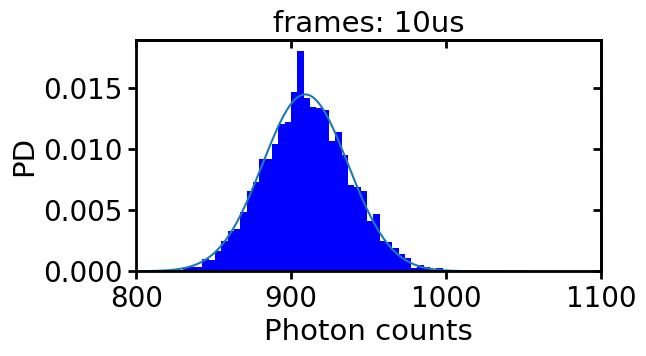

In [18]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=100,
                                                      xlim=[800, 1100])
ax[0].plot(x, normal)
#fig.savefig(r'C:\Users\SagixOffice\OneDrive - Universität Würzburg\Notebooks, plots\Plots\10µs_S0_S1', bbox_inches='tight')

## 0.1 ms

In [57]:
system.emitters(resample="0.1ms", photon_collection=1)

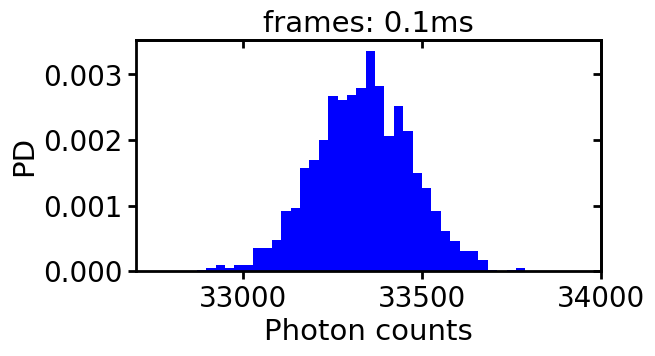

In [65]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=90,
                                                      xlim=[32700, 34000])#, pois=True)

## 1 ms

In [67]:
system.emitters(resample="1ms", photon_collection=1)

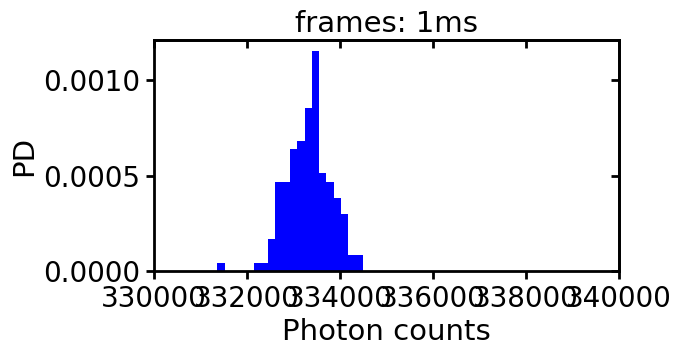

In [69]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=20,
                                                      xlim=[330000, 340000])

## 10 ms

In [111]:
system.emitters(unit="s", resample="10ms", photon_collection=0.1)

[9.99906763e+08]
5.965825659315398


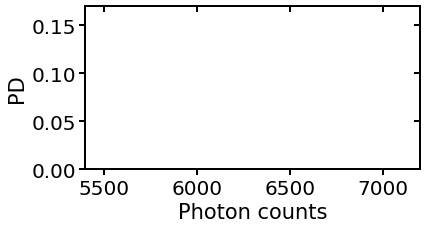

In [116]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=20,
                                                      xlim=[5400, 7200], pois=True)